## Imports

In [4]:
!pip install -q datasets transformers evaluate scikit-learn

In [11]:
import numpy as np
import random
import torch
from torch import nn
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import Trainer, TrainingArguments, PreTrainedModel, PretrainedConfig
import evaluate
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Generate Data

In [87]:
rng = np.random.default_rng(967)

def generate_benign(n=2000):
    rows = []
    for _ in range(n):
        entropy = rng.uniform(3.5, 6.5)   # normal range
        size = rng.integers(1024, 10_000_000)  # 1KB–10MB
        rows.append([entropy, size, 0])
    return rows

def generate_small_benign(n=500):
    rows = []
    for _ in range(n):
        entropy = rng.uniform(2.5, 6.5)   # configs/logs
        size = rng.integers(128, 4096)    # small but benign
        rows.append([entropy, size, 0])
    return rows

def generate_wiped(n=2000):
    rows = []
    for _ in range(n):
        if rng.random() < 0.5:
            entropy = rng.uniform(0.0, 1.0)   # all zeros
        else:
            entropy = rng.uniform(7.5, 8.0)   # random overwrite
        size = rng.choice([0, rng.integers(1, 512)])  # tiny suspicious files
        rows.append([entropy, size, 1])
    return rows

def generate_partial_wipe(n=1000):
    rows = []
    for _ in range(n):
        entropy = rng.uniform(2.0, 4.5)   # ambiguous mid‑range
        size = rng.integers(1024, 5_000_000)  # normal‑sized but partially wiped
        rows.append([entropy, size, 1])
    return rows

def generate_overlap_cases(n=1000):
    rows = []
    for _ in range(n):
        # Overlap: benign‑like entropy but suspicious size, or vice versa
        if rng.random() < 0.5:
            entropy = rng.uniform(3.5, 6.0)   # looks benign
            size = rng.integers(1, 512)       # looks wiped
            label = 0                         # actually benign
        else:
            entropy = rng.uniform(2.5, 6.0)   # looks benign
            size = rng.integers(1024, 10_000_000) # normal size
            label = 1                         # actually wiped
        rows.append([entropy, size, label])
    return rows

def generate_stress_dataset():
    benign = generate_benign(2000)
    small_benign = generate_small_benign(500)
    wiped = generate_wiped(2000)
    partial_wipe = generate_partial_wipe(1000)
    overlap = generate_overlap_cases(1000)

    data = benign + small_benign + wiped + partial_wipe + overlap
    random.shuffle(data)
    return data

    data = generate_dataset()

X = [row[:-1] for row in data]
y = [row[-1] for row in data]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

def to_records(X, y):
    return [{"input_ids": row, "label": int(lbl)} for row, lbl in zip(X, y)]

train_ds = Dataset.from_list(to_records(X_train, y_train))
test_ds  = Dataset.from_list(to_records(X_test, y_test))

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


train_ds = Dataset.from_list(to_records(X_train, y_train)).rename_column("label", "labels")
test_ds  = Dataset.from_list(to_records(X_test, y_test)).rename_column("label", "labels")

print(train_ds[0])

{'input_ids': [-1.5564636080702954, -0.7474979429133728], 'labels': 1}


## Model creation

In [88]:
weights = torch.tensor([1.0, 3.0])  # benign, wiped
loss_fn = nn.CrossEntropyLoss(weight=weights)

# class ImprovedTabularMLP(nn.Module):
#     def __init__(self, input_dim, num_classes=2):
#         super().__init__()
#         self.fc1 = nn.Linear(input_dim, 128)
#         self.bn1 = nn.BatchNorm1d(128)
#         self.fc2 = nn.Linear(128, 64)
#         self.fc3 = nn.Linear(64, 32)
#         self.dropout = nn.Dropout(0.15)
#         self.out = nn.Linear(32, num_classes)

#     def forward(self, input_ids, labels=None):
#         x1 = torch.relu(self.bn1(self.fc1(input_ids)))
#         x2 = torch.relu(self.fc2(x1))
#         x3 = torch.relu(self.fc3(x2) + x1[:, :32])  # residual shortcut
#         x3 = self.dropout(x3)
#         logits = self.out(x3)

#         loss = None
#         if labels is not None:
#             loss = nn.CrossEntropyLoss()(logits, labels)
#         return {"loss": loss, "logits": logits}


class RobustTabularMLP(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.residual_proj = nn.Linear(128, 32)  # cleaner residual
        self.dropout = nn.Dropout(0.12)
        self.out = nn.Linear(32, num_classes)
        self.loss_fn = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 3.0]))

    def forward(self, input_ids, labels=None):
        x1 = torch.relu(self.bn1(self.fc1(input_ids)))
        x2 = torch.relu(self.fc2(x1))
        x3 = torch.relu(self.fc3(x2) + self.residual_proj(x1))  # residual connection
        x3 = self.dropout(x3)
        logits = self.out(x3)

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels)
        return {"loss": loss, "logits": logits}


# ✅ Metrics setup
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision_score(labels, preds, average="macro"),
        "recall": recall_score(labels, preds, average="macro"),
        "f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

In [89]:
# args = TrainingArguments(
#     output_dir="./datawiping_detect",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=3e-4,              # slightly lower LR for stability
#     per_device_train_batch_size=32,
#     per_device_eval_batch_size=64,
#     num_train_epochs=40,             # reduce epochs to avoid overfitting
#     weight_decay=0.02,               # a bit stronger regularization
#     logging_steps=20,
#     remove_unused_columns=False,
#     load_best_model_at_end=True,     # ensures best checkpoint is restored
#     metric_for_best_model="f1",      # track F1 for balanced detection
#     greater_is_better=True,
#     dataloader_pin_memory=False

# )

args = TrainingArguments(
    output_dir="./datawiping_detect",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=50,
    weight_decay=0.02,
    logging_steps=20,
    remove_unused_columns=False,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    dataloader_pin_memory=False

)

In [90]:
input_dim = len(train_ds[0]["input_ids"])
hf_model = RobustTabularMLP(input_dim=input_dim, num_classes=2)

from transformers import EarlyStoppingCallback


trainer = Trainer(
    model=hf_model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=7)]
)

## Training

In [91]:
import wandb

wandb.init(
    project="data-wiping-detector",
    name="data_wiping_detection"
)

eval/accuracy,▁▄▆▆▇▇▅▆▇▇████▇▇████████
eval/f1,▁▄▆▆▇▇▅▆▇▇████▇▇████████
eval/loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/precision,▁▄▆▅▆▇▅▆▇▆█▇██▇▇████████
eval/recall,▁▄▆▆▇▇▅▆▇▇████▇▇████████
eval/runtime,▅▄▆█▄▄▄▁▁▁▁▂▃▂▅▃▃▂▁▂▁▂▁▁
eval/samples_per_second,▃▃▂▁▄▄▃▇███▇▅▅▃▄▄▅█▆▇▆██
eval/steps_per_second,▃▃▂▁▄▄▃▇███▇▅▅▃▄▄▅█▆▇▆██
test/accuracy,▁
test/f1,▁
+11,...


In [92]:
trainer.train()
metrics = trainer.evaluate()
metrics

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.258100,0.207069,0.870000,0.891823,0.870000,0.868164
2,0.107500,0.107657,0.926000,0.930658,0.926000,0.925799
3,0.089900,0.086296,0.941000,0.943428,0.941000,0.940919
4,0.082100,0.076253,0.950000,0.951851,0.950000,0.949949
5,0.075500,0.070072,0.957000,0.957661,0.957000,0.956984
6,0.065000,0.071894,0.968000,0.968000,0.968000,0.968000
7,0.073100,0.068489,0.946000,0.948873,0.946000,0.945913
8,0.077600,0.062831,0.954000,0.955867,0.954000,0.953953
9,0.065400,0.059581,0.964000,0.964476,0.964000,0.963991
10,0.073600,0.058876,0.963000,0.963417,0.963000,0.962992


{'eval_loss': 0.053291816264390945,
 'eval_accuracy': 0.975,
 'eval_precision': 0.9750171006156221,
 'eval_recall': 0.975,
 'eval_f1': 0.974999774997975,
 'eval_runtime': 0.0949,
 'eval_samples_per_second': 10539.114,
 'eval_steps_per_second': 168.626,
 'epoch': 25.0}

In [94]:
import torch
import numpy as np

# using scaler
# scaler = joblib.load("scaler.pkl")

def predict(sample_features):
    """
    sample_features: list or array [entropy, size]
    returns: "benign" or "wiped"
    """
    # Apply the same preprocessing as training
    # If you used StandardScaler:
    scaled = scaler.transform([sample_features])

    # Convert to tensor
    inputs = torch.tensor(scaled, dtype=torch.float32)

    # Forward pass
    hf_model.eval()
    with torch.no_grad():
        outputs = hf_model(inputs)
        logits = outputs["logits"]
        pred = torch.argmax(logits, dim=-1).item()

    return ["benign", "wiped"][pred]


In [95]:
# Typical text file
benign_sample1 = [4.2, 2048]     # entropy ~4.2, size 2 KB

# Normal executable
benign_sample2 = [5.8, 500000]   # entropy ~5.8, size ~500 KB

# Large image
benign_sample3 = [6.1, 3000000]  # entropy ~6.1, size ~3 MB

# Completely zeroed file
wiped_sample1 = [0.2, 0]         # entropy near 0, size 0

# Random overwrite
wiped_sample2 = [7.9, 256]       # entropy ~7.9, very small size

# Suspiciously tiny + low entropy
wiped_sample3 = [0.5, 128]       # entropy ~0.5, size 128 bytes

In [54]:
print("Benign 1:", predict(benign_sample1))
print("Benign 2:", predict(benign_sample2))
print("Benign 3:", predict(benign_sample3))

print("Wiped 1:", predict(wiped_sample1))
print("Wiped 2:", predict(wiped_sample2))
print("Wiped 3:", predict(wiped_sample3))


Benign 1: benign
Benign 2: benign
Benign 3: benign
Wiped 1: wiped
Wiped 2: wiped
Wiped 3: wiped


## AI Detection

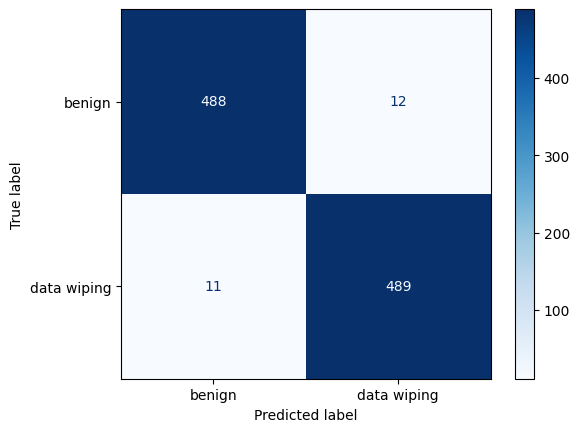

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

preds = trainer.predict(test_ds)
y_true = preds.label_ids
y_pred = (y_scores >= 0.55).astype(int)
#y_pred = np.argmax(preds.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign","data wiping"])
disp.plot(cmap="Blues")
plt.show()

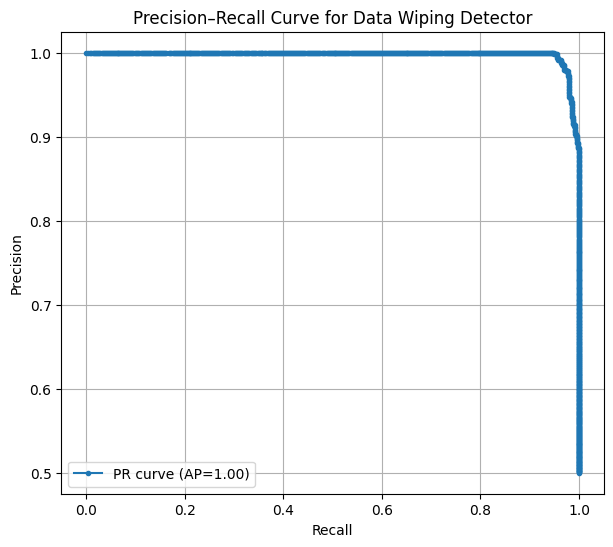

In [104]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score


# Run evaluation on your test set
predictions = trainer.predict(test_ds)

# predictions.predictions are the raw logits
logits = predictions.predictions
y_true = predictions.label_ids

import torch
import numpy as np

# Convert logits → probabilities for class 1 (wiped)
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_scores = probs[:, 1]   # probability of "wiped"


precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
avg_precision = average_precision_score(y_true, y_scores)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, marker='.', label=f'PR curve (AP={avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve for Data Wiping Detector')
plt.legend()
plt.grid(True)
plt.show()


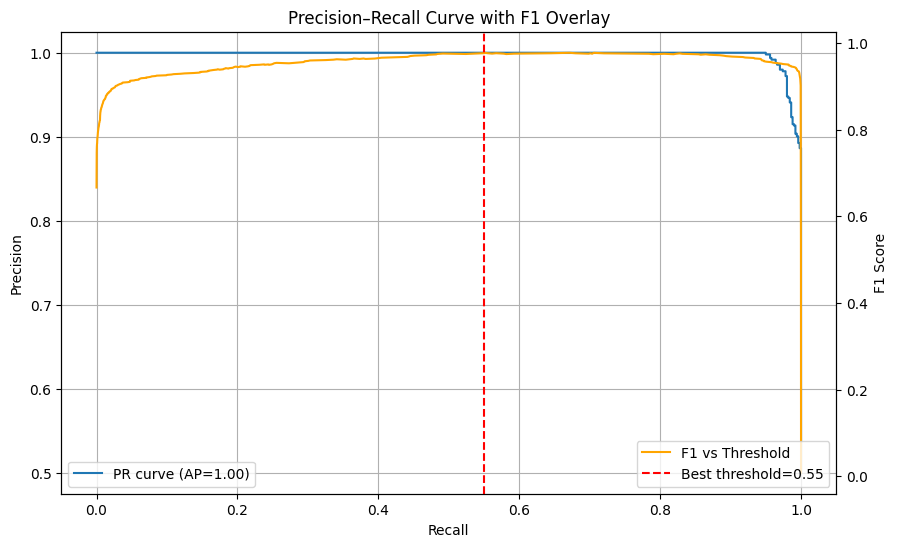

Best threshold: 0.55046725
Best F1: 0.978


In [106]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score

# y_true: ground truth labels (0=benign, 1=wiped)
# y_scores: predicted probabilities for class 1 (wiped)

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
avg_precision = average_precision_score(y_true, y_scores)

# Compute F1 at each threshold
f1_scores = []
for t in thresholds:
    y_pred = (y_scores >= t).astype(int)
    f1_scores.append(f1_score(y_true, y_pred))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# Plot PR curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'PR curve (AP={avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve with F1 Overlay')
plt.legend()
plt.grid(True)

# Plot F1 vs threshold on a secondary axis
plt.twinx()
plt.plot(thresholds, f1_scores, color='orange', label='F1 vs Threshold')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold={best_threshold:.2f}')
plt.ylabel('F1 Score')
plt.legend(loc='lower right')

plt.show()

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)


## Rule based detection

In [97]:
def rule_based_detect(row):
    entropy, size = row
    if entropy < 1.0 or entropy > 7.5 or size < 512:
        return 1  # wiped
    return 0      # benign


Rule-based accuracy: 0.5


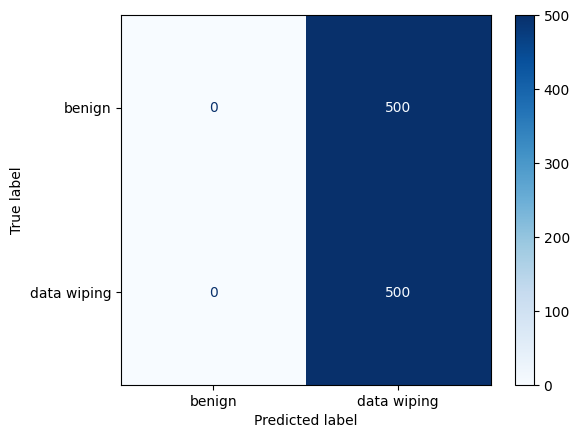

In [98]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Apply rule-based detection
y_pred_rule = [rule_based_detect(x) for x in X_test]

# Accuracy
acc = accuracy_score(y_test, y_pred_rule)
print("Rule-based accuracy:", acc)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rule, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign","data wiping"])
disp.plot(cmap="Blues")
plt.show()

In [99]:
import torch

# Save just the model weights
torch.save(hf_model.state_dict(), "datawiping_model_robust.pt")

# Save the scaler too (using joblib or pickle)
import joblib
joblib.dump(scaler, "scaler_datawiping_robust.pkl")


['scaler_datawiping_robust.pkl']

In [100]:
from google.colab import files
files.download("datawiping_model_robust.pt")
files.download("scaler_datawiping_robust.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp timestomp_model.pt /content/drive/MyDrive/
# !cp scaler.pkl /content/drive/MyDrive/

Mounted at /content/drive
